Parsed deterministic rows: 1000
Parsed Sto-SQP rows: 1000
Deterministic iteration range: 10 to 10000
Sto-SQP iteration range: 10 to 10000
Saved: burgers_main_mse_full_trajectory.png
Saved: burgers_main_mse_full_trajectory.pdf


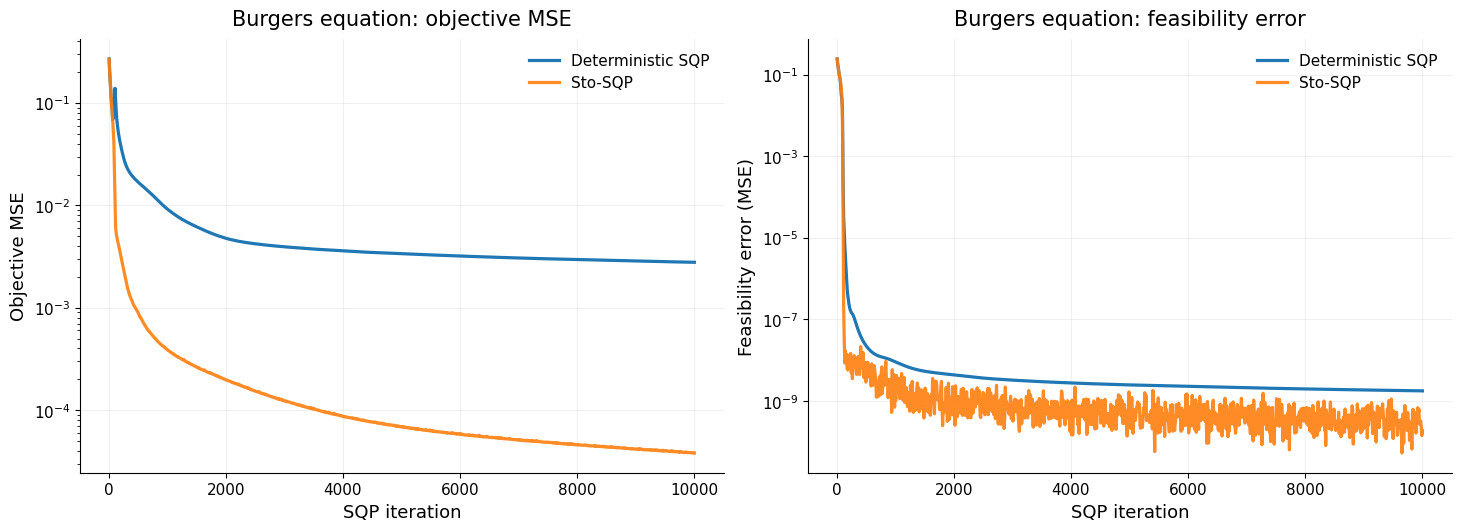

Saved: burgers_constraint_components_mse_full_trajectory.png
Saved: burgers_constraint_components_mse_full_trajectory.pdf


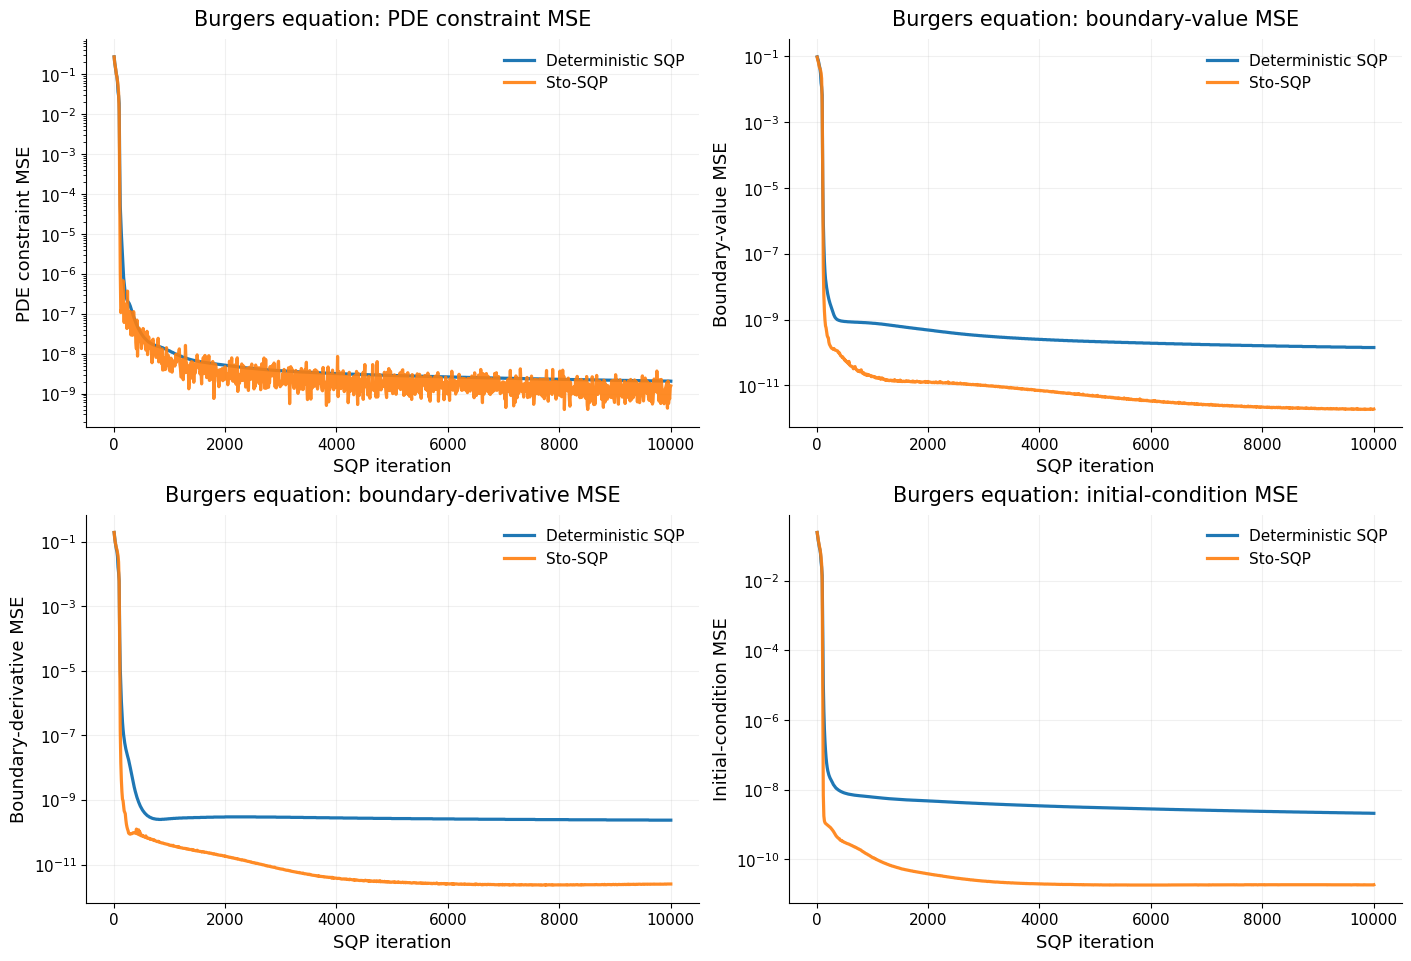

Saved: burgers_stosqp_constraint_components_full_trajectory.png
Saved: burgers_stosqp_constraint_components_full_trajectory.pdf


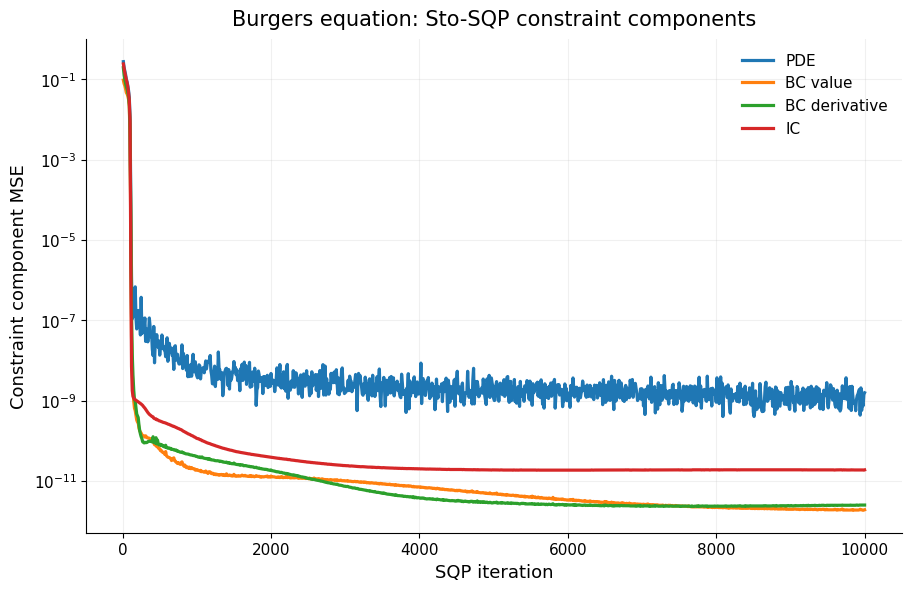


Done.
Main files:
  burgers_main_mse_full_trajectory.png
  burgers_main_mse_full_trajectory.pdf
  burgers_constraint_components_mse_full_trajectory.png
  burgers_constraint_components_mse_full_trajectory.pdf
  burgers_stosqp_constraint_components_full_trajectory.png
  burgers_stosqp_constraint_components_full_trajectory.pdf


In [ ]:
from pathlib import Path
import re
import csv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================
det_path = Path("burgers_deter.txt")   # deterministic SQP log
sto_path = Path("burgers_1e-5.txt")   # Sto-SQP log

eq_name = "Burgers equation"
OUT_DIR = Path(".")f

# Your printed PDE_obj_MSE is already unweighted:
# PDE_obj_MSE = mean(r^2)
# So do NOT divide by 10 here.


# ============================================================
# Parser
# ============================================================
def parse_sqp_log(path):
    text = path.read_text(errors="ignore")
    rows = []

    num = r"[+-]?\d+(?:\.\d+)?e[+-]?\d+"

    for line in text.splitlines():
        if "[iter=" not in line:
            continue

        it_match = re.search(r"\[iter=(\d+)\]", line)
        pde_obj_match = re.search(rf"PDE_obj_MSE=({num})", line)
        feas_match = re.search(rf"feas_true=({num})", line)

        pde_block = re.search(rf"PDE=\(({num}),({num})\)", line)
        bcv_block = re.search(rf"BCv=\(({num}),({num})\)", line)
        bcd_block = re.search(rf"BCd=\(({num}),({num})\)", line)
        ic_block  = re.search(rf"IC=\(({num}),({num})\)", line)

        if not (it_match and pde_obj_match and feas_match):
            continue

        pde_rms = float(pde_block.group(1)) if pde_block else np.nan
        bcv_rms = float(bcv_block.group(1)) if bcv_block else np.nan
        bcd_rms = float(bcd_block.group(1)) if bcd_block else np.nan
        ic_rms  = float(ic_block.group(1))  if ic_block  else np.nan

        rows.append({
            "iter": int(it_match.group(1)),

            # Main plot quantities
            "obj_mse": float(pde_obj_match.group(1)),
            "feas_mse": float(feas_match.group(1)),

            # Component constraint MSEs
            "pde_con_mse": pde_rms**2 if np.isfinite(pde_rms) else np.nan,
            "bcv_mse": bcv_rms**2 if np.isfinite(bcv_rms) else np.nan,
            "bcd_mse": bcd_rms**2 if np.isfinite(bcd_rms) else np.nan,
            "ic_mse": ic_rms**2 if np.isfinite(ic_rms) else np.nan,
        })

    rows = sorted(rows, key=lambda r: r["iter"])

    # Remove duplicate iteration rows if output was pasted twice
    dedup = {}
    for r in rows:
        dedup[r["iter"]] = r

    return list(dedup.values())


# ============================================================
# Load logs
# ============================================================
det_rows = parse_sqp_log(det_path)
sto_rows = parse_sqp_log(sto_path)

if len(det_rows) == 0:
    raise RuntimeError(f"No SQP iteration rows parsed from {det_path}")
if len(sto_rows) == 0:
    raise RuntimeError(f"No SQP iteration rows parsed from {sto_path}")

print("Parsed deterministic rows:", len(det_rows))
print("Parsed Sto-SQP rows:", len(sto_rows))
print("Deterministic iteration range:", det_rows[0]["iter"], "to", det_rows[-1]["iter"])
print("Sto-SQP iteration range:", sto_rows[0]["iter"], "to", sto_rows[-1]["iter"])


# ============================================================
# Save parsed CSV
# ============================================================
def save_csv(rows, filename):
    fieldnames = list(rows[0].keys())
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

save_csv(det_rows, OUT_DIR / "burgers_det_sqp_fulltraj_parsed.csv")
save_csv(sto_rows, OUT_DIR / "burgers_sto_sqp_fulltraj_parsed.csv")


# ============================================================
# Helpers
# ============================================================
def col(rows, key):
    return np.array([r[key] for r in rows], dtype=float)

det_iter = col(det_rows, "iter")
sto_iter = col(sto_rows, "iter")


# ============================================================
# Plot style
# ============================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.3,
})


def beautify_axis(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.set_yscale("log")

    # Clean grid
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    ax.grid(False, which="minor")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def savefig(fig, basename):
    png = OUT_DIR / f"{basename}.png"
    pdf = OUT_DIR / f"{basename}.pdf"

    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print("Saved:", png)
    print("Saved:", pdf)


# ============================================================
# Figure 1: main full-trajectory plot
# Objective MSE + Feasibility error MSE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), constrained_layout=True)

axes[0].plot(det_iter, col(det_rows, "obj_mse"), label="Deterministic SQP")
axes[0].plot(sto_iter, col(sto_rows, "obj_mse"), label="Sto-SQP", alpha=0.90)
beautify_axis(
    axes[0],
    "SQP iteration",
    "Objective MSE",
    f"{eq_name}: objective MSE",
)
axes[0].legend(frameon=False)

axes[1].plot(det_iter, col(det_rows, "feas_mse"), label="Deterministic SQP")
axes[1].plot(sto_iter, col(sto_rows, "feas_mse"), label="Sto-SQP", alpha=0.90)
beautify_axis(
    axes[1],
    "SQP iteration",
    "Feasibility error (MSE)",
    f"{eq_name}: feasibility error",
)
axes[1].legend(frameon=False)

savefig(fig, "burgers_main_mse_full_trajectory")
plt.show()


# ============================================================
# Figure 2: full-trajectory constraint component MSEs
# ============================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9.5), constrained_layout=True)

panels = [
    ("pde_con_mse", "PDE constraint MSE", f"{eq_name}: PDE constraint MSE"),
    ("bcv_mse", "Boundary-value MSE", f"{eq_name}: boundary-value MSE"),
    ("bcd_mse", "Boundary-derivative MSE", f"{eq_name}: boundary-derivative MSE"),
    ("ic_mse", "Initial-condition MSE", f"{eq_name}: initial-condition MSE"),
]

for ax, (key, ylabel, title) in zip(axes2.ravel(), panels):
    ax.plot(det_iter, col(det_rows, key), label="Deterministic SQP")
    ax.plot(sto_iter, col(sto_rows, key), label="Sto-SQP", alpha=0.90)
    beautify_axis(ax, "SQP iteration", ylabel, title)
    ax.legend(frameon=False)

savefig(fig2, "burgers_constraint_components_mse_full_trajectory")
plt.show()


# ============================================================
# Figure 3: Sto-SQP component overlay, full trajectory
# ============================================================
fig3, ax3 = plt.subplots(figsize=(9, 5.8), constrained_layout=True)

ax3.plot(sto_iter, col(sto_rows, "pde_con_mse"), label="PDE")
ax3.plot(sto_iter, col(sto_rows, "bcv_mse"), label="BC value")
ax3.plot(sto_iter, col(sto_rows, "bcd_mse"), label="BC derivative")
ax3.plot(sto_iter, col(sto_rows, "ic_mse"), label="IC")

beautify_axis(
    ax3,
    "SQP iteration",
    "Constraint component MSE",
    f"{eq_name}: Sto-SQP constraint components",
)
ax3.legend(frameon=False)

savefig(fig3, "burgers_stosqp_constraint_components_full_trajectory")
plt.show()


print("\nDone.")
print("Main files:")
print("  burgers_main_mse_full_trajectory.png")
print("  burgers_main_mse_full_trajectory.pdf")
print("  burgers_constraint_components_mse_full_trajectory.png")
print("  burgers_constraint_components_mse_full_trajectory.pdf")
print("  burgers_stosqp_constraint_components_full_trajectory.png")
print("  burgers_stosqp_constraint_components_full_trajectory.pdf")

Saved: burgers_deterministic_sqp_constraint_components_full_trajectory.png
Saved: burgers_deterministic_sqp_constraint_components_full_trajectory.pdf


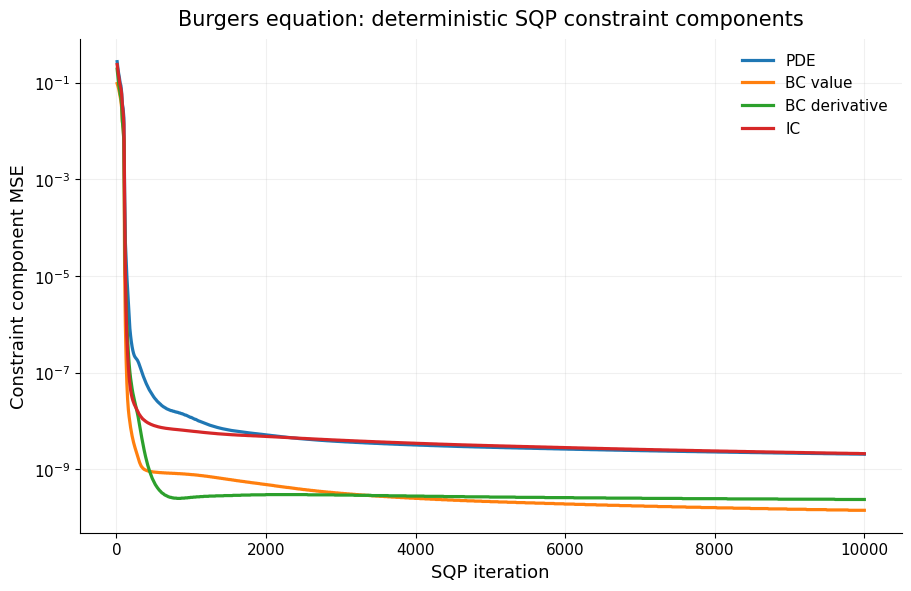

In [10]:
# ============================================================
# Figure 4: Deterministic SQP component overlay, full trajectory
# ============================================================
fig4, ax4 = plt.subplots(figsize=(9, 5.8), constrained_layout=True)

ax4.plot(det_iter, col(det_rows, "pde_con_mse"), label="PDE")
ax4.plot(det_iter, col(det_rows, "bcv_mse"), label="BC value")
ax4.plot(det_iter, col(det_rows, "bcd_mse"), label="BC derivative")
ax4.plot(det_iter, col(det_rows, "ic_mse"), label="IC")

beautify_axis(
    ax4,
    "SQP iteration",
    "Constraint component MSE",
    f"{eq_name}: deterministic SQP constraint components",
)
ax4.legend(frameon=False)

savefig(fig4, "burgers_deterministic_sqp_constraint_components_full_trajectory")
plt.show()

Parsed undamped rows: 1000
Parsed damped rows: 1000
Undamped iteration range: 10 to 10000
Damped iteration range: 10 to 10000
Undamped objective source: ['PDE_obj_MSE']
Damped objective source: ['PDE_obj_MSE']
Undamped printed mu values: [0.0]
Damped printed mu values: []
Saved: burgers_damped_vs_undamped_objective_pde_mse.png
Saved: burgers_damped_vs_undamped_objective_pde_mse.pdf


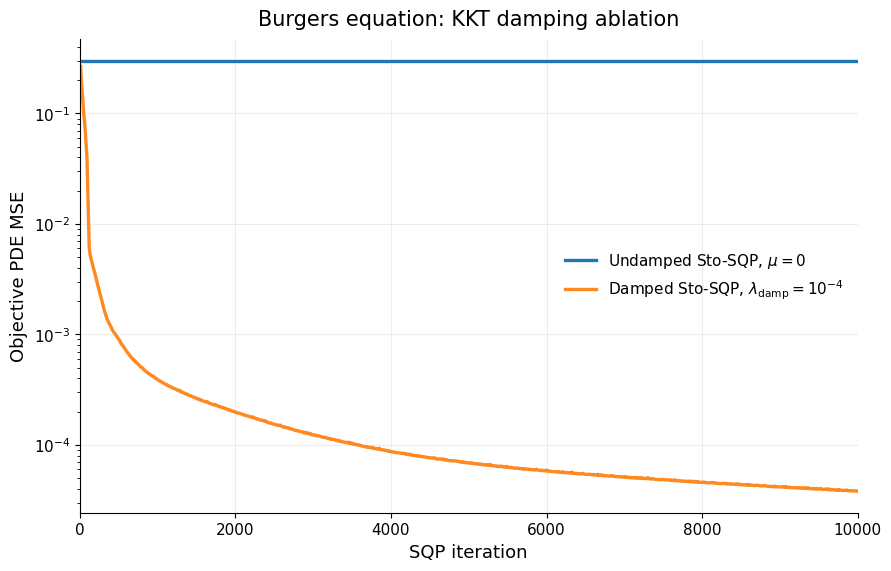

Saved: burgers_damped_vs_undamped_objective_and_feasibility.png
Saved: burgers_damped_vs_undamped_objective_and_feasibility.pdf


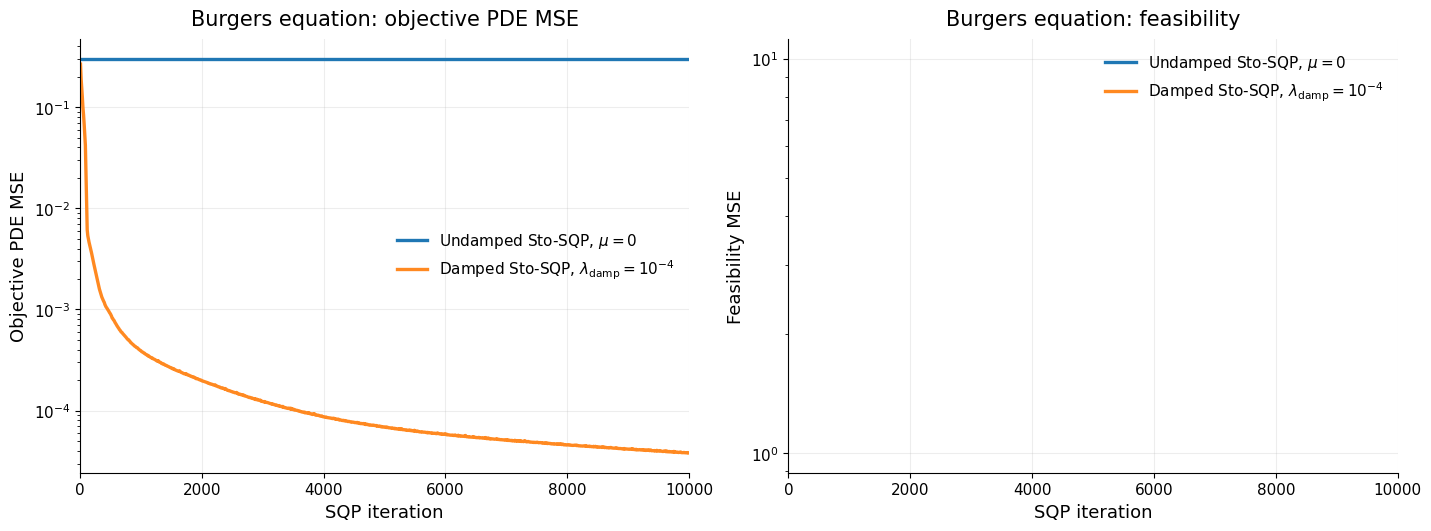


Comparison at horizon: 10000.0
Undamped objective = 2.999000e-01 at iter 10000
Damped objective   = 3.812000e-05 at iter 10000
Undamped / Damped objective ratio = 7.867e+03
Undamped feasibility = nan at iter 10000
Damped feasibility   = nan at iter 10000


: 

In [ ]:
from pathlib import Path
import re
import csv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================
# Undamped: same stochastic jitter, but KKT damping disabled, e.g. mu = 0
UNDAMPED_LOG = Path("burgers_licq.txt")

# Damped: same stochastic jitter, but KKT damping enabled, e.g. lambda_damp = 1e-4
DAMPED_LOG = Path("burgers_1e-5.txt")

OUT_DIR = Path(".")
EQ_NAME = "Burgers equation"

# Main plotted quantity:
# PDE_obj_MSE is unweighted objective-point PDE MSE, so it is fair
# even if the internal weighted objective uses different coefficients.
PLOT_QUANTITY = "unweighted_pde_mse"

# These are only used if PDE_obj_MSE is missing and obj_s must be converted.
OBJ_WEIGHT_UNDAMPED = 1.0
OBJ_WEIGHT_DAMPED = 10.0

# Compare only over the common horizon. Useful if the undamped run stops early.
PLOT_COMMON_HORIZON = True

# Also create an optional two-panel figure with feasibility.
MAKE_TWO_PANEL = True


# ============================================================
# Robust parser
# ============================================================
NUM = r"(?:nan|inf|-inf|[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"

def to_float(s):
    try:
        return float(s)
    except Exception:
        return np.nan


def first_number(pattern, text, default=np.nan):
    m = re.search(pattern, text, flags=re.IGNORECASE)
    return to_float(m.group(1)) if m else default


def parse_sqp_log(path: Path, obj_weight: float):
    """
    Parse SQP log.

    Main fields:
        iter
        pde_obj_mse      unweighted objective-point PDE MSE, if printed
        obj_s            raw weighted/scaled objective, if printed
        obj_for_plot     chosen objective quantity for plot
        feas_true        true feasibility MSE, if printed
        mu, lam          printed damping values if available
    """
    text = path.read_text(errors="ignore")
    rows = []

    for line in text.splitlines():
        if "[iter=" not in line:
            continue

        it_match = re.search(r"\[iter=(\d+)\]", line)
        if not it_match:
            continue

        it = int(it_match.group(1))

        obj_s = first_number(rf"\bobj_s=({NUM})", line)
        pde_obj_mse = first_number(rf"\bPDE_obj_MSE=({NUM})", line)
        feas_true = first_number(rf"\bfeas_true=({NUM})", line)

        # Optional diagnostics
        alpha = first_number(rf"\balpha=({NUM})", line)
        tau = first_number(rf"\btau=({NUM})", line)
        lam = first_number(rf"\blam=({NUM})", line)
        mu = first_number(rf"\bmu=({NUM})", line)
        kkt_res = first_number(rf"\bkkt_res=({NUM})", line)

        d_inf = first_number(rf"\|\|d\|\|_inf=({NUM})", line)
        d_l2 = first_number(rf"\|\|d\|\|_l2=({NUM})", line)

        # Prefer unweighted PDE_obj_MSE.
        if PLOT_QUANTITY == "unweighted_pde_mse":
            if np.isfinite(pde_obj_mse):
                obj_for_plot = pde_obj_mse
                source = "PDE_obj_MSE"
            elif np.isfinite(obj_s):
                obj_for_plot = obj_s / obj_weight
                source = f"obj_s / {obj_weight:g}"
            else:
                obj_for_plot = np.nan
                source = "missing"

        elif PLOT_QUANTITY == "weighted_objective":
            if np.isfinite(obj_s):
                obj_for_plot = obj_s
                source = "obj_s"
            elif np.isfinite(pde_obj_mse):
                obj_for_plot = obj_weight * pde_obj_mse
                source = f"{obj_weight:g} * PDE_obj_MSE"
            else:
                obj_for_plot = np.nan
                source = "missing"
        else:
            raise ValueError("PLOT_QUANTITY must be 'unweighted_pde_mse' or 'weighted_objective'.")

        rows.append({
            "iter": it,
            "obj_s": obj_s,
            "pde_obj_mse": pde_obj_mse,
            "feas_true": feas_true,
            "obj_for_plot": obj_for_plot,
            "source": source,
            "alpha": alpha,
            "tau": tau,
            "lam": lam,
            "mu": mu,
            "kkt_res": kkt_res,
            "d_inf": d_inf,
            "d_l2": d_l2,
        })

    rows = sorted(rows, key=lambda r: r["iter"])

    # De-duplicate by iteration, keeping latest occurrence.
    dedup = {}
    for r in rows:
        dedup[r["iter"]] = r
    rows = list(dedup.values())

    rows = [r for r in rows if np.isfinite(r["obj_for_plot"])]

    if len(rows) == 0:
        raise RuntimeError(f"No usable SQP iteration rows parsed from {path}")

    return rows


def col(rows, key):
    return np.array([r[key] for r in rows], dtype=float)


# ============================================================
# Load logs
# ============================================================
undamped_rows = parse_sqp_log(UNDAMPED_LOG, OBJ_WEIGHT_UNDAMPED)
damped_rows = parse_sqp_log(DAMPED_LOG, OBJ_WEIGHT_DAMPED)

print("Parsed undamped rows:", len(undamped_rows))
print("Parsed damped rows:", len(damped_rows))
print("Undamped iteration range:", undamped_rows[0]["iter"], "to", undamped_rows[-1]["iter"])
print("Damped iteration range:", damped_rows[0]["iter"], "to", damped_rows[-1]["iter"])
print("Undamped objective source:", sorted(set(r["source"] for r in undamped_rows)))
print("Damped objective source:", sorted(set(r["source"] for r in damped_rows)))

print("Undamped printed mu values:", sorted({r["mu"] for r in undamped_rows if np.isfinite(r["mu"])})[:5])
print("Damped printed mu values:", sorted({r["mu"] for r in damped_rows if np.isfinite(r["mu"])})[:5])


# ============================================================
# Save parsed CSVs
# ============================================================
def save_csv(rows, filename):
    fieldnames = [
        "iter", "obj_s", "pde_obj_mse", "feas_true", "obj_for_plot", "source",
        "alpha", "tau", "lam", "mu", "kkt_res", "d_inf", "d_l2"
    ]
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

save_csv(undamped_rows, OUT_DIR / "burgers_undamped_stosqp_parsed.csv")
save_csv(damped_rows, OUT_DIR / "burgers_damped_stosqp_parsed.csv")


# ============================================================
# Plot style
# ============================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.4,
})


def beautify_axis(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.set_yscale("log")
    ax.grid(True, which="major", alpha=0.22, linewidth=0.8)
    ax.grid(False, which="minor")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ============================================================
# Prepare arrays
# ============================================================
undamped_iter = col(undamped_rows, "iter")
undamped_obj = col(undamped_rows, "obj_for_plot")
undamped_feas = col(undamped_rows, "feas_true")

damped_iter = col(damped_rows, "iter")
damped_obj = col(damped_rows, "obj_for_plot")
damped_feas = col(damped_rows, "feas_true")

if PLOT_COMMON_HORIZON:
    xmax = min(np.max(undamped_iter), np.max(damped_iter))
else:
    xmax = max(np.max(undamped_iter), np.max(damped_iter))


# ============================================================
# Figure 1: objective PDE MSE only
# ============================================================
fig, ax = plt.subplots(figsize=(8.8, 5.6), constrained_layout=True)

ax.plot(
    undamped_iter,
    undamped_obj,
    label=r"Undamped Sto-SQP, $\mu=0$",
    linewidth=2.4,
)

ax.plot(
    damped_iter,
    damped_obj,
    label=r"Damped Sto-SQP, $\lambda_{\rm damp}=10^{-4}$",
    linewidth=2.4,
    alpha=0.92,
)

beautify_axis(
    ax,
    "SQP iteration",
    "Objective PDE MSE",
    f"{EQ_NAME}: KKT damping ablation",
)

ax.set_xlim(0, xmax)
ax.legend(frameon=False, loc="best")

basename = "burgers_damped_vs_undamped_objective_pde_mse"
png_path = OUT_DIR / f"{basename}.png"
pdf_path = OUT_DIR / f"{basename}.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

print("Saved:", png_path)
print("Saved:", pdf_path)

plt.show()


# ============================================================
# Figure 2: optional objective + feasibility two-panel figure
# ============================================================
if MAKE_TWO_PANEL:
    fig2, axes = plt.subplots(1, 2, figsize=(14.2, 5.2), constrained_layout=True)

    axes[0].plot(
        undamped_iter,
        undamped_obj,
        label=r"Undamped Sto-SQP, $\mu=0$",
        linewidth=2.4,
    )
    axes[0].plot(
        damped_iter,
        damped_obj,
        label=r"Damped Sto-SQP, $\lambda_{\rm damp}=10^{-4}$",
        linewidth=2.4,
        alpha=0.92,
    )
    beautify_axis(
        axes[0],
        "SQP iteration",
        "Objective PDE MSE",
        f"{EQ_NAME}: objective PDE MSE",
    )
    axes[0].set_xlim(0, xmax)
    axes[0].legend(frameon=False, loc="best")

    axes[1].plot(
        undamped_iter,
        undamped_feas,
        label=r"Undamped Sto-SQP, $\mu=0$",
        linewidth=2.4,
    )
    axes[1].plot(
        damped_iter,
        damped_feas,
        label=r"Damped Sto-SQP, $\lambda_{\rm damp}=10^{-4}$",
        linewidth=2.4,
        alpha=0.92,
    )
    beautify_axis(
        axes[1],
        "SQP iteration",
        "Feasibility MSE",
        f"{EQ_NAME}: feasibility",
    )
    axes[1].set_xlim(0, xmax)
    axes[1].legend(frameon=False, loc="best")

    basename2 = "burgers_damped_vs_undamped_objective_and_feasibility"
    png_path2 = OUT_DIR / f"{basename2}.png"
    pdf_path2 = OUT_DIR / f"{basename2}.pdf"

    fig2.savefig(png_path2, dpi=300, bbox_inches="tight")
    fig2.savefig(pdf_path2, bbox_inches="tight")

    print("Saved:", png_path2)
    print("Saved:", pdf_path2)

    plt.show()


# ============================================================
# Print comparison at common horizon
# ============================================================
def last_on_horizon(rows, horizon):
    valid = [r for r in rows if r["iter"] <= horizon]
    return valid[-1]

horizon = xmax

undamped_last = last_on_horizon(undamped_rows, horizon)
damped_last = last_on_horizon(damped_rows, horizon)

print("\nComparison at horizon:", horizon)
print(f"Undamped objective = {undamped_last['obj_for_plot']:.6e} at iter {undamped_last['iter']}")
print(f"Damped objective   = {damped_last['obj_for_plot']:.6e} at iter {damped_last['iter']}")

if np.isfinite(undamped_last["obj_for_plot"]) and np.isfinite(damped_last["obj_for_plot"]):
    ratio = undamped_last["obj_for_plot"] / damped_last["obj_for_plot"]
    print(f"Undamped / Damped objective ratio = {ratio:.3e}")

print(f"Undamped feasibility = {undamped_last['feas_true']:.6e} at iter {undamped_last['iter']}")
print(f"Damped feasibility   = {damped_last['feas_true']:.6e} at iter {damped_last['iter']}")